In [1]:
# ==== CELL 1: Data Retrieval ====
# Read site IDs from text file and retrieve USGS discharge measurements
from dataretrieval import nwis
from IPython.display import display
import pandas as pd
from pathlib import Path

def read_site_ids(file_path):
    """
    Read site IDs from a text file and clean them up.
    Removes 'USGS' prefix and any whitespace.
    """
    with open(file_path, 'r') as file:
        lines = file.readlines()
    
    # Clean up the site IDs: remove 'USGS', strip whitespace, filter empty lines
    site_ids = []
    for line in lines:
        line = line.strip()  # Remove leading/trailing whitespace
        if line:  # Skip empty lines
            # Remove 'USGS' prefix if present (case insensitive)
            if line.upper().startswith('USGS '):
                site_id = line[5:]  # Remove 'USGS ' (5 characters)
            else:
                site_id = line
            site_ids.append(site_id.strip())
    
    return site_ids

# Path to your text file with site IDs
site_file_path = r"C:\Users\aeliz\Dropbox\Documents\Jupyter Notebooks\chap2_usgs\data\original_data\stream_sb_usgs.txt"

try:
    # Read and clean site IDs
    sites = read_site_ids(site_file_path)
    print(f"Found {len(sites)} site IDs:")
    print(sites[:10])  # Show first 10 sites as preview
    if len(sites) > 10:
        print(f"... and {len(sites) - 10} more sites")
    
    # Retrieve discharge measurements from all sites
    print(f"\nRetrieving discharge measurements from {len(sites)} USGS sites...")
    sb_streams = nwis.get_discharge_measurements(
        sites=sites, 
        start="1800-01-01", 
        end="1979-12-31"
    )
    
    print("Retrieved " + str(len(sb_streams[0])) + " data values.")
    print(f"Data columns: {sb_streams[0].columns.tolist()}")  # Show column names for verification
    display(sb_streams[0].head())  # Show first few rows instead of entire dataframe
    
    # Create output directory if it doesn't exist
    output_dir = Path("output")
    output_dir.mkdir(exist_ok=True)
    
    # Save to CSV
    csv_path = r"C:\Users\aeliz\Dropbox\Documents\Jupyter Notebooks\chap2_usgs\output\sb_streamflow_usgs_1800_1979.csv"
    sb_streams[0].to_csv(csv_path, index=False)
    print(f"Saved {len(sb_streams[0]):,} streamflow measurements to: {csv_path}")
    
    # Verify the file was written successfully
    if Path(csv_path).exists():
        file_size = Path(csv_path).stat().st_size
        print(f"File successfully written. Size: {file_size:,} bytes")
    else:
        print("WARNING: CSV file was not created successfully")
    
except FileNotFoundError:
    print(f"Error: Could not find the file '{site_file_path}'")
    print("Please update the 'site_file_path' variable with the correct path to your text file.")
except Exception as e:
    print(f"An error occurred: {e}")
    import traceback
    traceback.print_exc()

print("=== DATA RETRIEVAL COMPLETE ===")
print("You can now run the processing cell...")


Found 83 site IDs:
['11119500', '11119530', '11119660', '11119700', '11119745', '11119750', '11119760', '11119770', '11119780', '11119900']
... and 73 more sites

Retrieving discharge measurements from 83 USGS sites...
Retrieved 1948 data values.
Data columns: ['agency_cd', 'site_no', 'measurement_nu', 'measurement_dt', 'tz_cd', 'q_meas_used_fg', 'party_nm', 'site_visit_coll_agency_cd', 'gage_height_va', 'discharge_va', 'measured_rating_diff', 'gage_va_change', 'gage_va_time', 'control_type_cd', 'discharge_cd']


,agency_cd,site_no,measurement_nu,measurement_dt,tz_cd,q_meas_used_fg,party_nm,site_visit_coll_agency_cd,gage_height_va,discharge_va,measured_rating_diff,gage_va_change,gage_va_time,control_type_cd,discharge_cd
0,USGS,11119500,1,1940-12-31,NaN,Yes,UNK,USGS,2.02,0.25,Good,0.00,0.2,NaN,NONE
1,USGS,11119500,2,1941-01-07,NaN,Yes,UNK,USGS,2.49,13.40,Unspecified,0.00,0.4,NaN,NONE
2,USGS,11119500,3,1941-01-08,NaN,Yes,UNK,USGS,2.38,8.20,Good,0.00,0.3,NaN,NONE
3,USGS,11119500,4,1941-01-09,NaN,Yes,UNK,USGS,2.34,5.50,Unspecified,0.00,0.3,NaN,NONE
4,USGS,11119500,5,1941-01-22,NaN,Yes,UNK,USGS,2.39,8.70,Good,-0.01,0.3,NaN,NONE


Saved 1,948 streamflow measurements to: C:\Users\aeliz\Dropbox\Documents\Jupyter Notebooks\chap2_usgs\output\sb_streamflow_usgs_1800_1979.csv
File successfully written. Size: 148,193 bytes
=== DATA RETRIEVAL COMPLETE ===
You can now run the processing cell...


In [16]:
# ==== CELL 2: Data Processing ====
print("\n=== PROCESSING STREAMFLOW NWIS DATA ===")

import pandas as pd
from pathlib import Path
import numpy as np

# Load the streamflow CSV data
csv_path = r"C:\Users\aeliz\Dropbox\Documents\Jupyter Notebooks\chap2_usgs\output\sb_streamflow_usgs_1800_1979.csv"

try:
    # Check if file exists before trying to read it
    if not Path(csv_path).exists():
        raise FileNotFoundError(f"CSV file not found at {csv_path}")
    
    # Load the streamflow measurements
    sb_streamflow = pd.read_csv(csv_path)
    print(f"Loaded {len(sb_streamflow):,} streamflow measurements")
    
    # Display basic info about the data
    print(f"Columns: {sb_streamflow.columns.tolist()}")
    
    # Check if measurement_dt column exists
    if 'measurement_dt' not in sb_streamflow.columns:
        print("Available columns:", sb_streamflow.columns.tolist())
        raise KeyError("Column 'measurement_dt' not found in the data. Please check column names.")
    
    print(f"Date range in measurement_dt: {sb_streamflow['measurement_dt'].min()} to {sb_streamflow['measurement_dt'].max()}")
    
    # ---------------------------------------------------------------------
    # PATCH 1: Flexible date parsing with *safe* 2-digit-year handling
    # ---------------------------------------------------------------------
    import re
    from datetime import datetime

    # Formats that use a 4-digit year (no 2-digit fix needed)
    FMTS_FULL_YEAR = [
        '%Y-%m-%d %H:%M:%S',
        '%Y-%m-%d %H:%M',
        '%Y-%m-%d',
        '%m/%d/%Y %H:%M:%S',
        '%m/%d/%Y %H:%M',
        '%m/%d/%Y',
        '%m-%d-%Y',
        '%d-%b-%Y',   # 05-Oct-1987
        '%b-%d-%Y',
    ]

    # Formats that use a 2-digit year (apply the 2-digit rule)
    FMTS_TWO_DIGIT_YEAR = [
        '%d-%b-%y',   # 05-Oct-87
        '%b-%d-%y',
        '%m/%d/%y',   # 9/17/78
        '%m-%d-%y',
        '%d-%m-%y',
    ]

    # Regex patterns that clearly indicate a 2-digit *year* in the string
    # (used only as a fallback guard, not for ordinary 4-digit cases like 1941-01-07)
    TWO_DIGIT_YEAR_PATTERNS = [
        r'^\d{1,2}/\d{1,2}/\d{2}(?:\s|$)',
        r'^\d{1,2}-\d{1,2}-\d{2}(?:\s|$)',
        r'^\d{1,2}-[A-Za-z]{3}-\d{2}(?:\s|$)',
        r'^[A-Za-z]{3}-\d{1,2}-\d{2}(?:\s|$)',
    ]

    def _map_two_digit_year(yy: int) -> int:
        """Project 2-digit year using your rule."""
        return 1900 + yy if 0 <= yy <= 80 else 1800 + yy

    def parse_flexible_date(s):
        if pd.isna(s):
            return pd.NaT
        s = str(s).strip()
        if not s:
            return pd.NaT

        # 1) Try formats with 4-digit years first (no remap)
        for fmt in FMTS_FULL_YEAR:
            try:
                dt = datetime.strptime(s, fmt)
                year = dt.year
                return pd.Timestamp(dt) if 1800 <= year <= 1979 else pd.NaT
            except Exception:
                pass

        # 2) Try formats that *do* use 2-digit years, then remap safely
        for fmt in FMTS_TWO_DIGIT_YEAR:
            try:
                dt = datetime.strptime(s, fmt)
                yy = dt.year % 100
                year = _map_two_digit_year(yy)
                try:
                    dt = dt.replace(year=year)
                except Exception:
                    return pd.NaT
                return pd.Timestamp(dt) if 1800 <= year <= 1979 else pd.NaT
            except Exception:
                pass

        # 3) Fallback to pandas parser. Only apply 2-digit remap if the *string*
        #    clearly matches a 2-digit-year pattern (to avoid touching YYYY-MM-DD).
        dt = pd.to_datetime(s, errors='coerce')
        if pd.isna(dt):
            return pd.NaT

        # If the string *looks like* it used a 2-digit year, remap by the last %y
        if any(re.match(pat, s) for pat in TWO_DIGIT_YEAR_PATTERNS):
            yy = dt.year % 100
            year = _map_two_digit_year(yy)
            try:
                dt = dt.to_pydatetime().replace(year=year)
            except Exception:
                return pd.NaT
        # Else: string had a clear 4-digit year → leave as-is

        return pd.Timestamp(dt) if 1800 <= dt.year <= 1979 else pd.NaT

    # Keep a raw copy for verification/debugging (optional but helpful)
    sb_streamflow['measurement_dt_raw'] = sb_streamflow['measurement_dt']

    print("Converting dates to datetime format (safe flexible parser)...")
    sb_streamflow['measurement_dt'] = sb_streamflow['measurement_dt'].apply(parse_flexible_date)
    sb_streamflow['year'] = sb_streamflow['measurement_dt'].dt.year.astype('Int64')  # nullable int

    # ==== Summary 1: Each unique site ID with start year, end year, and total measurements ====
    print("\n=== CREATING SITE SUMMARY (Start Year, End Year, Total Measurements, Decades) ===")
    
    site_summary = sb_streamflow.groupby('site_no').agg({
        'year': ['min', 'max'],  # First/earliest year and last/latest year
        'measurement_dt': 'count'  # Total number of measurements
    }).reset_index()
    
    # Flatten the multi-level column names
    site_summary.columns = ['site_no', 'start_year', 'end_year', 'total_measurements']

    # Ensure integer year dtype where possible
    site_summary['start_year'] = site_summary['start_year'].astype('Int64')
    site_summary['end_year']   = site_summary['end_year'].astype('Int64')
    
    # Calculate the span of years for each site
    site_summary['year_span'] = site_summary['end_year'] - site_summary['start_year'] + 1
    
    # --- NEW: Decade fields (nullable Int64) ---
    site_summary['decade_start'] = ((site_summary['start_year'] // 10) * 10).astype('Int64')
    site_summary['decade_end']   = ((site_summary['end_year']   // 10) * 10).astype('Int64')
    site_summary['decade']       = site_summary['decade_start']  # single source of truth
    
    # Sort by start year then site number
    site_summary = site_summary.sort_values(['start_year', 'site_no'])
    
    print(f"Created summary for {len(site_summary):,} unique sites")
    print("Sample of site summary with decades:")
    print(site_summary.head())
    
    # Save summary 1
    output_dir = Path("output")
    output_dir.mkdir(exist_ok=True)
    
    summary1_path = output_dir / "sb_streamflow_sites_start_end_years.csv"
    site_summary.to_csv(summary1_path, index=False)
    print(f"Saved site summary with start/end years: {summary1_path}")
    
    # ==== Summary 2: Each unique site ID and each unique year it has measurements ====
    print("\n=== CREATING SITE-YEAR SUMMARY (All Years) ===")
    
    # Get unique combinations of site_no and year, with measurement count per year
    site_year_summary = sb_streamflow.groupby(['site_no', 'year']).agg({
        'measurement_dt': 'count'  # Number of measurements in this year
    }).reset_index()
    
    # Rename column for clarity
    site_year_summary.columns = ['site_no', 'year', 'measurements_in_year']

    # Ensure integer year dtype
    site_year_summary['year'] = site_year_summary['year'].astype('Int64')

    # --- NEW: convenience decade column on the yearly table ---
    site_year_summary['decade'] = ((site_year_summary['year'] // 10) * 10).astype('Int64')
    
    # Sort by site number then year
    site_year_summary = site_year_summary.sort_values(['site_no', 'year'])
    
    print(f"Created site-year summary with {len(site_year_summary):,} site-year combinations")
    print("Sample of site-year summary:")
    print(site_year_summary.head(10))
    
    # Save summary 2
    summary2_path = output_dir / "sb_streamflow_sites_all_years.csv"
    site_year_summary.to_csv(summary2_path, index=False)
    print(f"Saved site-year summary: {summary2_path}")
    
    # ==== Additional Analysis ====
    print("\n=== ADDITIONAL ANALYSIS ===")
    
    print("Site measurement statistics:")
    measurement_stats = site_summary['total_measurements'].describe()
    print(measurement_stats)
    
    print(f"\nYear span statistics:")
    span_stats = site_summary['year_span'].describe()
    print(span_stats)
    
    print(f"\nDecade distribution of start years:")
    decade_start_counts = site_summary['decade_start'].value_counts().sort_index()
    print(decade_start_counts)

    print(f"\nDecade distribution of end years:")
    decade_end_counts = site_summary['decade_end'].value_counts().sort_index()
    print(decade_end_counts)
    
    print(f"\nSites with most measurements:")
    top_sites = site_summary.nlargest(5, 'total_measurements')[['site_no', 'start_year', 'end_year', 'total_measurements', 'year_span', 'decade_start', 'decade_end']]
    print(top_sites)
    
    print(f"\nEarliest starting sites:")
    earliest_sites = site_summary.nsmallest(5, 'start_year')[['site_no', 'start_year', 'end_year', 'total_measurements', 'year_span', 'decade_start', 'decade_end']]
    print(earliest_sites)
    
    print(f"\nSites with longest monitoring periods:")
    longest_span = site_summary.nlargest(5, 'year_span')[['site_no', 'start_year', 'end_year', 'total_measurements', 'year_span', 'decade_start', 'decade_end']]
    print(longest_span)
    
    # ==== Create a visualization-ready summary for the decadal analysis ====
    print("\n=== CREATING DECADE SUMMARY FOR MAPPING ===")
    
    # Add decade fields to mapping output
    site_mapping_summary = site_summary.copy()
    site_mapping_summary['decade'] = site_mapping_summary['decade_start']  # alias retained
    
    summary3_path = output_dir / "sb_streamflow_sites_for_mapping.csv"
    site_mapping_summary.to_csv(summary3_path, index=False)
    print(f"Saved mapping summary: {summary3_path}")
    
    print(f"\n=== SUMMARY FILES CREATED ===")
    print(f"1. Site start/end years: {summary1_path}")
    print(f"2. Site-year combinations: {summary2_path}")
    print(f"3. Mapping ready: {summary3_path}")

except FileNotFoundError:
    print(f"ERROR: Could not find the streamflow CSV file at: {csv_path}")
    print("Make sure you've run the data retrieval cell first and that it completed successfully.")
    print("Check that the CSV file was actually created in the expected location.")
except KeyError as e:
    print(f"ERROR: Missing expected column in the data: {e}")
    print("The data structure may have changed. Check the column names in your CSV file.")
except Exception as e:
    print(f"ERROR processing data: {e}")
    print("Check that your CSV file has the expected columns (site_no, measurement_dt, etc.)")
    import traceback
    traceback.print_exc()



=== PROCESSING STREAMFLOW NWIS DATA ===
Loaded 1,948 streamflow measurements
Columns: ['agency_cd', 'site_no', 'measurement_nu', 'measurement_dt', 'tz_cd', 'q_meas_used_fg', 'party_nm', 'site_visit_coll_agency_cd', 'gage_height_va', 'discharge_va', 'measured_rating_diff', 'gage_va_change', 'gage_va_time', 'control_type_cd', 'discharge_cd']
Date range in measurement_dt: 1940-12-31 to 1979-12-26
Converting dates to datetime format (safe flexible parser)...

=== CREATING SITE SUMMARY (Start Year, End Year, Total Measurements, Decades) ===
Created summary for 21 unique sites
Sample of site summary with decades:
     site_no  start_year  end_year  total_measurements  year_span  \
0   11119500        1940      1979                 509         40   
5   11120500        1941      1979                1015         39   
9   11123500        1952      1979                  28         28   
12  11132500        1952      1978                  27         27   
18  11138500        1952      1979     

In [15]:
# ==== PREP: Load Historical (Restored) Stream Sites for Santa Ynez Filter ====
print("=== LOADING HISTORICAL (RESTORED) STREAM SITES ===")

import os
import pandas as pd
import geopandas as gpd
from pathlib import Path

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

# --------------------------
# Helpers: standardize names
# --------------------------
def _to_numeric(s):
    return pd.to_numeric(s, errors='coerce')

def standardize_years_and_coords(df: pd.DataFrame) -> pd.DataFrame:
    """Create canonical columns without overwriting originals:
       - start_year, end_year (from year_start/start_year & year_end/end_year)
       - longitude, latitude (from lon_combined/lat_combined & longitude/latitude)
       - decade_start, decade_end, decade (alias of decade_start)
    """
    out = df.copy()

    # ---- Coordinates → longitude / latitude (prefer *_combined, then native) ----
    lon_sources = []
    lat_sources = []

    if 'lon_combined' in out.columns:
        lon_sources.append(_to_numeric(out['lon_combined']))
    if 'longitude' in out.columns:
        lon_sources.append(_to_numeric(out['longitude']))

    if 'lat_combined' in out.columns:
        lat_sources.append(_to_numeric(out['lat_combined']))
    if 'latitude' in out.columns:
        lat_sources.append(_to_numeric(out['latitude']))

    if lon_sources:
        lon = lon_sources[0]
        for s in lon_sources[1:]:
            lon = lon.combine_first(s)
        out['longitude'] = lon
    else:
        out['longitude'] = pd.NA

    if lat_sources:
        lat = lat_sources[0]
        for s in lat_sources[1:]:
            lat = lat.combine_first(s)
        out['latitude'] = lat
    else:
        out['latitude'] = pd.NA

    # ---- Years → start_year / end_year (min of starts, max of ends) ----
    start_candidates = []
    for c in ['year_start', 'start_year']:
        if c in out.columns:
            start_candidates.append(_to_numeric(out[c]))
    if start_candidates:
        start_year = start_candidates[0]
        for s in start_candidates[1:]:
            start_year = pd.concat([start_year, s], axis=1).min(axis=1, skipna=True)
    else:
        start_year = pd.Series(pd.NA, index=out.index, dtype="Float64")
    out['start_year'] = start_year

    end_candidates = []
    for c in ['year_end', 'end_year']:
        if c in out.columns:
            end_candidates.append(_to_numeric(out[c]))
    if end_candidates:
        end_year = end_candidates[0]
        for s in end_candidates[1:]:
            end_year = pd.concat([end_year, s], axis=1).max(axis=1, skipna=True)
    else:
        end_year = pd.Series(pd.NA, index=out.index, dtype="Float64")
    out['end_year'] = end_year

    # ---- Decades (nullable Int64) ----
    out['decade_start'] = ((out['start_year'] // 10) * 10).astype('Int64')
    out['decade_end']   = ((out['end_year']   // 10) * 10).astype('Int64')
    out['decade']       = out['decade_start']  # single source of truth

    # Optional span
    if 'start_year' in out and 'end_year' in out:
        out['year_span'] = (out['end_year'] - out['start_year'] + 1)

    return out

# --------------------------
# 1) Load enhanced artifacts
# --------------------------
from artifacts_io import load_artifacts
tables, meta, run_dir = load_artifacts(out_dir="artifacts")
print(f"Loaded artifacts from: {run_dir}")

if "df_combined" in tables:
    restored_df_all = tables["df_combined"].copy()
    print(f"Using df_combined: {len(restored_df_all):,} total rows")
elif "df" in tables:
    restored_df_all = tables["df"].copy()
    print(f"Using df: {len(restored_df_all):,} total rows")
else:
    k = max(tables, key=lambda key: tables[key].shape[0])
    restored_df_all = tables[k].copy()
    print(f"Using {k}: {len(restored_df_all):,} total rows")

# --------------------------------------------
# 2) Filter to Santa Barbara County (if ready)
# --------------------------------------------
sb_county_shapefile = r"C:\Users\aeliz\Dropbox\Documents\Jupyter Notebooks\chap2_usgs\data\sb_county_shapefile\sb_county_shp.shp"

def _filter_to_sb(df_in: pd.DataFrame) -> pd.DataFrame:
    try:
        sb_county = gpd.read_file(sb_county_shapefile)
        if sb_county.crs is None or sb_county.crs.to_string() != "EPSG:4326":
            sb_county = sb_county.to_crs("EPSG:4326")
        sb_geom = sb_county.union_all() if hasattr(sb_county, "union_all") else sb_county.unary_union

        # Determine available coordinate columns just to make a temporary GeoDF
        if {'lon_combined','lat_combined'}.issubset(df_in.columns):
            _lon, _lat = 'lon_combined','lat_combined'
        elif {'longitude','latitude'}.issubset(df_in.columns):
            _lon, _lat = 'longitude','latitude'
        else:
            # If neither present yet, try to standardize minimally for filtering
            temp = standardize_years_and_coords(df_in)
            _lon, _lat = 'longitude','latitude'
            tmp_gdf = gpd.GeoDataFrame(
                temp,
                geometry=gpd.points_from_xy(temp[_lon], temp[_lat]),
                crs="EPSG:4326"
            )
            mask = tmp_gdf.within(sb_geom)
            out = temp.loc[mask].copy()
            print(f"Filtered to Santa Barbara County (via temp standardization): {len(out):,} rows (from {len(df_in):,})")
            return out

        gdf = gpd.GeoDataFrame(
            df_in,
            geometry=gpd.points_from_xy(df_in[_lon], df_in[_lat]),
            crs="EPSG:4326"
        )
        mask = gdf.within(sb_geom)
        out = df_in.loc[mask].copy()
        print(f"Filtered to Santa Barbara County: {len(out):,} rows (from {len(df_in):,})")
        return out
    except Exception as e:
        print(f"WARNING: Could not filter to Santa Barbara County ({e}). Using full dataset.")
        return df_in.copy()

restored_df = _filter_to_sb(restored_df_all)

# ---------------------------------------------------
# 3) Keep only Stream discharge, then standardize all
# ---------------------------------------------------
if 'water_type_clean' not in restored_df.columns:
    raise KeyError("Column 'water_type_clean' not found in restored artifacts.")

subset = restored_df[restored_df['water_type_clean'] == 'Stream discharge'].copy()
print(f"Historical stream discharge sites (pre-standardization): {len(subset):,}")

historical_streams = standardize_years_and_coords(subset)
print(f"Historical stream discharge sites (standardized): {len(historical_streams):,}")

# ---------------------------------------------------
# 4) Expose canonical coordinate cols for downstream
# ---------------------------------------------------
historical_coord_cols = ['longitude','latitude']

# -------------------------
# 5) Sanity prints (optional)
# -------------------------
keep_preview = [c for c in ['year_start','start_year','year_end','end_year',
                            'decade_start','decade_end','decade',
                            'lon_combined','lat_combined','longitude','latitude']
                if c in historical_streams.columns]

print("\n=== STANDARDIZATION PREVIEW ===")
print("Columns shown:", keep_preview)
if keep_preview:
    print(historical_streams[keep_preview].head(8))

missing_coords = historical_streams[['longitude','latitude']].isna().any(axis=1).sum()
if missing_coords:
    print(f"NOTE: {missing_coords} rows missing canonical longitude/latitude")

print("=== HISTORICAL STREAMS READY ===")


=== LOADING HISTORICAL (RESTORED) STREAM SITES ===
Loaded artifacts from: artifacts\run_20250901_113434
Using df_combined: 109,626 total rows
Filtered to Santa Barbara County: 6,786 rows (from 109,626)
Historical stream discharge sites (pre-standardization): 2,516
Historical stream discharge sites (standardized): 2,516

=== STANDARDIZATION PREVIEW ===
Columns shown: ['year_start', 'start_year', 'year_end', 'end_year', 'decade_start', 'decade_end', 'decade', 'longitude', 'latitude']
     year_start  start_year  year_end  end_year  decade_start  decade_end  \
105        1913        1913      1914      1914          1910        1910   
120        1940        1940      1960      1960          1940        1960   
166        1954        1954      1957      1957          1950        1950   
269        1949        1949      1950      1950          1940        1950   
373        1920        1920      1969      1969          1920        1960   
382        1960        1960      1961      1961    

In [17]:
# ==== FILTER HISTORICAL SITES FOR SANTA YNEZ RIVER ====
print("=== FILTERING FOR SANTA YNEZ RIVER SITES ===")

import re
import os
from matplotlib.lines import Line2D

# First, let's examine what columns we have in historical_streams
print("Available columns in historical_streams:")
print(list(historical_streams.columns))
print(f"\nTotal historical stream sites: {len(historical_streams)}")

# Look for columns that might contain location or water source information
location_columns = [col for col in historical_streams.columns if any(keyword in col.lower() for keyword in ['location', 'name', 'source', 'station', 'site'])]
print(f"\nPotential location/name columns: {location_columns}")

# Create a function to search for Santa Ynez River variations
def contains_santa_ynez(text):
    """
    Check if text contains Santa Ynez River or variations
    Case insensitive search for various spellings
    """
    try:
        # Handle various data types that might be in the columns
        if text is None:
            return False
        if hasattr(text, '__len__') and not isinstance(text, str):
            # Handle arrays, lists, etc. - convert to string
            text_str = str(text).lower()
        elif pd.isna(text):
            return False
        elif text == '':
            return False
        else:
            text_str = str(text).lower()
        
        # Define patterns for Santa Ynez River variations
        patterns = [
            r'santa\s+ynez\s+r',  # Santa Ynez R (river abbreviated)
            r'santa\s+ynez\s+river',  # Santa Ynez River
            r'santa\s+inez\s+r',  # Alternative spelling: Santa Inez
            r'santa\s+inez\s+river',
            r'sta\s+ynez',  # Abbreviated Santa
            r'st\s+ynez',   # Another abbreviation
            r'santa\s+yanez', # Alternative spelling
            r'sante\s+ynez', # Misspelling
        ]
        
        for pattern in patterns:
            if re.search(pattern, text_str):
                return True
        return False
    except Exception as e:
        # If any error occurs, return False and continue
        return False

# Search through all potential columns (excluding problematic ones)
santa_ynez_sites = pd.DataFrame()
search_results = {}

# Define columns to skip
skip_columns = ['keyterms']

for col in historical_streams.columns:
    if col in skip_columns:
        print(f"Skipping column '{col}' (known to cause issues)")
        continue
        
    if historical_streams[col].dtype == 'object':  # Only search text columns
        try:
            matches = historical_streams[historical_streams[col].apply(contains_santa_ynez)]
            if len(matches) > 0:
                search_results[col] = len(matches)
                print(f"\nFound {len(matches)} matches in column '{col}'")
                # Show some example values
                examples = matches[col].unique()[:5]
                print(f"Examples: {list(examples)}")
        except Exception as e:
            print(f"Error searching column '{col}': {e}")
            continue

# Combine all matches (remove duplicates by index)
all_matches_indices = set()
for col in historical_streams.columns:
    if col in skip_columns:
        continue
        
    if historical_streams[col].dtype == 'object':
        try:
            matches_idx = historical_streams[historical_streams[col].apply(contains_santa_ynez)].index
            all_matches_indices.update(matches_idx)
        except Exception as e:
            print(f"Error processing column '{col}': {e}")
            continue

# Get all Santa Ynez sites
santa_ynez_sites = historical_streams.loc[list(all_matches_indices)].copy()

print(f"\n=== SANTA YNEZ RIVER SITES FOUND ===")
print(f"Total Santa Ynez River historical sites: {len(santa_ynez_sites)}")

# ==== LOAD HUC8 WATERSHED FOR SPATIAL FILTERING ====
print(f"\n=== LOADING SANTA YNEZ WATERSHED BOUNDARY ===")

# Load HUC8 watershed first (needed for NWIS spatial filtering)
try:
    huc8_path = r"C:\Users\aeliz\Dropbox\Documents\Jupyter Notebooks\chap2_usgs\data\santaynezhuc8\santaynez.shp"
    huc8_watershed = gpd.read_file(huc8_path)
    if huc8_watershed.crs != "EPSG:4326":
        huc8_watershed = huc8_watershed.to_crs("EPSG:4326")
    print(f"✓ Loaded Santa Ynez HUC8 watershed with {len(huc8_watershed)} feature(s)")
    print(f"Watershed bounds: {huc8_watershed.bounds}")
    watershed_loaded = True
except Exception as e:
    print(f"✗ Failed to load HUC8 watershed: {e}")
    huc8_watershed = None
    watershed_loaded = False

# ==== SPATIALLY FILTER NWIS SITES BY WATERSHED BOUNDARY ====
print(f"\n=== SPATIALLY FILTERING NWIS SITES BY WATERSHED BOUNDARY ===")

# Check if NWIS sites are available
if 'nwis_sites_gdf' in globals():
    print(f"Total NWIS sites available: {len(nwis_sites_gdf)}")
    
    if watershed_loaded and huc8_watershed is not None:
        # Ensure both datasets have the same CRS
        if nwis_sites_gdf.crs != huc8_watershed.crs:
            print(f"Converting NWIS sites CRS from {nwis_sites_gdf.crs} to {huc8_watershed.crs}")
            nwis_sites_temp = nwis_sites_gdf.to_crs(huc8_watershed.crs)
        else:
            nwis_sites_temp = nwis_sites_gdf.copy()
        
        # Perform spatial intersection to find NWIS sites within the Santa Ynez watershed
        print("Performing spatial intersection...")
        try:
            nwis_santa_ynez_gdf = gpd.sjoin(nwis_sites_temp, huc8_watershed, how='inner', predicate='within')
            
            # Remove duplicate geometry column if it exists
            if 'geometry_right' in nwis_santa_ynez_gdf.columns:
                nwis_santa_ynez_gdf = nwis_santa_ynez_gdf.drop('geometry_right', axis=1)
            
            print(f"✓ Found {len(nwis_santa_ynez_gdf)} NWIS sites within Santa Ynez watershed")
            
            if len(nwis_santa_ynez_gdf) > 0:
                # Show some details about spatially filtered NWIS sites
                print(f"\nSpatially filtered NWIS Santa Ynez sites details:")
                display_cols = [col for col in ['station_id', 'station_nm', 'site_nm', 'latitude', 'longitude', 'data_type'] if col in nwis_santa_ynez_gdf.columns]
                if display_cols:
                    print(nwis_santa_ynez_gdf[display_cols].head())
                
                # Show coordinate bounds of filtered sites
                bounds = nwis_santa_ynez_gdf.bounds
                print(f"\nSpatial extent of NWIS sites:")
                print(f"Latitude range: {bounds['miny'].min():.4f} to {bounds['maxy'].max():.4f}")
                print(f"Longitude range: {bounds['minx'].min():.4f} to {bounds['maxx'].max():.4f}")
            
        except Exception as e:
            print(f"✗ Error in spatial intersection: {e}")
            nwis_santa_ynez_gdf = gpd.GeoDataFrame()
    else:
        print("✗ Cannot perform spatial filtering: watershed boundary not available")
        nwis_santa_ynez_gdf = gpd.GeoDataFrame()
        
else:
    print("NWIS sites not found. Make sure nwis_sites_gdf is loaded.")
    nwis_santa_ynez_gdf = gpd.GeoDataFrame()

# ==== COMBINE HISTORICAL AND NWIS SITES ====
if len(santa_ynez_sites) > 0 or len(nwis_santa_ynez_gdf) > 0:
    # Show summary information for historical sites
    if len(santa_ynez_sites) > 0:
        print(f"\nHistorical sites columns with matches: {list(search_results.keys())}")
        
        # FIXED: Check for BOTH naming conventions for year columns
        year_cols = []
        potential_year_cols = ['year_start', 'year_end', 'start_year', 'end_year']
        for col in potential_year_cols:
            if col in santa_ynez_sites.columns:
                year_cols.append(col)
        
        # Also check for any other columns with 'year' in the name
        other_year_cols = [col for col in santa_ynez_sites.columns if 'year' in col.lower() and col not in year_cols]
        year_cols.extend(other_year_cols)
        
        print(f"Available year columns: {year_cols}")
        
        if year_cols:
            for year_col in year_cols:
                if santa_ynez_sites[year_col].notna().any():
                    try:
                        # Check if the column contains arrays/lists or scalar values
                        sample_value = santa_ynez_sites[year_col].dropna().iloc[0] if len(santa_ynez_sites[year_col].dropna()) > 0 else None
                        
                        if sample_value is not None:
                            if hasattr(sample_value, '__len__') and not isinstance(sample_value, str):
                                # Column contains arrays/lists - flatten them
                                all_years = []
                                for val in santa_ynez_sites[year_col].dropna():
                                    if hasattr(val, '__len__') and not isinstance(val, str):
                                        all_years.extend([y for y in val if pd.notna(y)])
                                    else:
                                        if pd.notna(val):
                                            all_years.append(val)
                                
                                if all_years:
                                    min_year = min(all_years)
                                    max_year = max(all_years)
                                    print(f"Year range in {year_col}: {min_year} - {max_year}")
                                else:
                                    print(f"No valid years found in {year_col}")
                            else:
                                # Column contains scalar values
                                min_year = santa_ynez_sites[year_col].min()
                                max_year = santa_ynez_sites[year_col].max()
                                print(f"Year range in {year_col}: {min_year} - {max_year}")
                    except Exception as e:
                        print(f"Error processing year column {year_col}: {e}")
                        # Try to show some sample values to understand the data structure
                        print(f"Sample values in {year_col}:")
                        sample_vals = santa_ynez_sites[year_col].dropna().head(3).tolist()
                        print(sample_vals)
        
        # Show decade distribution if available
        if 'decade' in santa_ynez_sites.columns:
            print(f"\nDecade distribution:")
            decade_counts = santa_ynez_sites['decade'].value_counts().sort_index()
            print(decade_counts)
        elif 'start_decade' in santa_ynez_sites.columns:
            print(f"\nStart decade distribution:")
            decade_counts = santa_ynez_sites['start_decade'].value_counts().sort_index()
            print(decade_counts)
    
    # ==== CREATE GEODATAFRAMES FOR MAPPING ====
    print(f"\n=== CREATING GEODATAFRAMES FOR MAPPING ===")
    
    # Create historical sites GeoDataFrame
    if len(santa_ynez_sites) > 0:
        santa_ynez_gdf = gpd.GeoDataFrame(
            santa_ynez_sites,
            geometry=gpd.points_from_xy(santa_ynez_sites[historical_coord_cols[0]], santa_ynez_sites[historical_coord_cols[1]]),
            crs="EPSG:4326"
        )
        santa_ynez_gdf['data_type'] = 'Historical'
        print(f"Created Historical Santa Ynez GeoDataFrame with {len(santa_ynez_gdf)} sites")
    else:
        santa_ynez_gdf = gpd.GeoDataFrame()
    
    # Combine historical and NWIS sites
    all_santa_ynez_sites = []
    
    if len(santa_ynez_gdf) > 0:
        all_santa_ynez_sites.append(santa_ynez_gdf)
        
    if len(nwis_santa_ynez_gdf) > 0:
        all_santa_ynez_sites.append(nwis_santa_ynez_gdf)
    
    if all_santa_ynez_sites:
        # Combine all Santa Ynez sites
        combined_santa_ynez_gdf = gpd.GeoDataFrame(pd.concat(all_santa_ynez_sites, ignore_index=True))
        print(f"Combined Santa Ynez GeoDataFrame: {len(combined_santa_ynez_gdf)} total sites")
        
        # Show breakdown by data type
        if 'data_type' in combined_santa_ynez_gdf.columns:
            type_counts = combined_santa_ynez_gdf['data_type'].value_counts()
            print(f"Sites by data type:")
            for dtype, count in type_counts.items():
                print(f"  {dtype}: {count} sites")
    else:
        combined_santa_ynez_gdf = gpd.GeoDataFrame()
        print("No Santa Ynez sites found in either dataset")
    
    # Display detailed information about each site
    if len(combined_santa_ynez_gdf) > 0:
        print(f"\n=== DETAILED SANTA YNEZ RIVER SITES ===")
        
        # FIXED: Select relevant columns for display with both naming conventions
        display_cols = []
        potential_display_cols = [
            'site_id', 'station_id', 'station_name', 'station_nm', 'site_nm', 'location', 'water_source_name',
            'year_start', 'year_end', 'start_year', 'end_year',  # Both naming conventions
            'decade', 'start_decade', 'end_decade',  # Both naming conventions
            'data_source', 'data_type'
        ]
        
        for col in potential_display_cols:
            if col in combined_santa_ynez_gdf.columns:
                display_cols.append(col)
        
        # Add coordinate columns
        coord_cols = ['longitude', 'latitude']
        for col in coord_cols:
            if col in combined_santa_ynez_gdf.columns:
                display_cols.append(col)
        
        print(f"Displaying columns: {display_cols}")
        pd.set_option('display.max_columns', None)
        pd.set_option('display.width', None)
        
        if display_cols:
            print(combined_santa_ynez_gdf[display_cols])
    
    # ==== LOAD RIVERS DATA WITH FIONA ====
    print(f"\n=== LOADING RIVERS DATA WITH FIONA ===")
    
    def load_rivers_with_fiona(gdb_path, shp_path):
        """
        Load rivers data using fiona
        """
        try:
            import fiona
            print("✓ Fiona available")
        except ImportError:
            print("Installing fiona...")
            import subprocess
            import sys
            
            try:
                # Install fiona
                subprocess.check_call([sys.executable, "-m", "pip", "install", "fiona"])
                print("✓ Fiona installed successfully")
                import fiona
            except Exception as e:
                print(f"✗ Failed to install fiona: {e}")
                return None
        
        try:
            # First try the geodatabase
            if gdb_path and os.path.exists(gdb_path):
                print(f"Loading geodatabase with fiona: {gdb_path}")
                
                # List all layers in the geodatabase
                layers = fiona.listlayers(gdb_path)
                print(f"Layers in geodatabase: {layers}")
                
                # Look for river/stream layers
                river_keywords = ['stream', 'river', 'water', 'hydro', 'flow', 'streamsandrivers']
                potential_layers = []
                
                for layer in layers:
                    layer_lower = layer.lower()
                    if any(keyword in layer_lower for keyword in river_keywords):
                        potential_layers.append(layer)
                
                print(f"Potential river layers: {potential_layers}")
                
                # Try the most promising layer
                target_layer = None
                if potential_layers:
                    target_layer = potential_layers[0]
                elif layers:
                    target_layer = layers[0]  # Fallback to first layer
                
                if target_layer:
                    print(f"Loading layer: {target_layer}")
                    
                    # Check layer info with fiona
                    with fiona.open(gdb_path, layer=target_layer) as src:
                        print(f"Layer CRS: {src.crs}")
                        print(f"Layer schema: {src.schema}")
                        print(f"Feature count: {len(src)}")
                        print(f"Bounds: {src.bounds}")
                    
                    # Load with geopandas
                    rivers = gpd.read_file(gdb_path, layer=target_layer)
                    print(f"✓ Successfully loaded {len(rivers)} features using fiona")
                    return rivers
            
            # Try the shapefile if geodatabase failed
            if shp_path and os.path.exists(shp_path):
                print(f"Loading shapefile with fiona: {shp_path}")
                
                # Check shapefile info
                with fiona.open(shp_path) as src:
                    print(f"Shapefile CRS: {src.crs}")
                    print(f"Shapefile schema: {src.schema}")
                    print(f"Feature count: {len(src)}")
                    print(f"Bounds: {src.bounds}")
                
                # Load with geopandas
                rivers = gpd.read_file(shp_path)
                print(f"✓ Successfully loaded {len(rivers)} features from shapefile using fiona")
                return rivers
                
        except Exception as e:
            print(f"✗ Fiona loading failed: {e}")
            return None
        
        return None
    
    # Define paths
    rivers_gdb_path = r"C:\Users\aeliz\Dropbox\Documents\Jupyter Notebooks\chap2_usgs\data\rivers\chap2map.gdb"
    rivers_shp_path = r"C:\Users\aeliz\Dropbox\Documents\Jupyter Notebooks\chap2_usgs\data\rivers\StreamsandRivers_Clip.shp"
    
    # Check if files exist
    gdb_exists = os.path.exists(rivers_gdb_path)
    shp_exists = os.path.exists(rivers_shp_path)
    
    print(f"Geodatabase exists: {gdb_exists} - {rivers_gdb_path}")
    print(f"Shapefile exists: {shp_exists} - {rivers_shp_path}")
    
    # Load with Fiona
    rivers = load_rivers_with_fiona(rivers_gdb_path if gdb_exists else None,
                                   rivers_shp_path if shp_exists else None)
    
    # Final check and processing
    if rivers is not None:
        print(f"\n✓ RIVERS DATA LOADED SUCCESSFULLY!")
        print(f"Rivers data contains {len(rivers)} features")
        print(f"Available columns: {list(rivers.columns)}")
        print(f"Geometry types: {rivers.geometry.geom_type.unique()}")
        
        # Ensure correct CRS
        if rivers.crs is not None and rivers.crs != "EPSG:4326":
            print(f"Converting CRS from {rivers.crs} to EPSG:4326")
            rivers = rivers.to_crs("EPSG:4326")
        
        print("Rivers data ready for mapping")
        
        # Show sample of attribute table
        print(f"\nSample of rivers attribute table:")
        display_cols = [col for col in rivers.columns if col != 'geometry'][:5]
        print(rivers[display_cols].head())
        
    else:
        print("\n✗ FAILED TO LOAD RIVERS DATA")
        print("Please check file paths and permissions")
    
    print(f"\n=== DATA LOADING COMPLETE ===")
    print(f"Santa Ynez historical sites: {len(santa_ynez_gdf) if len(santa_ynez_sites) > 0 else 0}")
    print(f"Santa Ynez NWIS sites: {len(nwis_santa_ynez_gdf)}")
    print(f"Total Santa Ynez sites: {len(combined_santa_ynez_gdf) if len(combined_santa_ynez_gdf) > 0 else 0}")
    print(f"Rivers data: {'✓ Loaded' if rivers is not None else '✗ Failed'}")
    print(f"HUC8 watershed: {'✓ Loaded' if watershed_loaded else '✗ Failed'}")

else:
    print("No Santa Ynez River sites found in either historical or NWIS data.")
    print("Check column names and search patterns.")
    print("\nFirst few rows of historical_streams for reference:")
    display_cols = [col for col in historical_streams.columns if any(keyword in col.lower() for keyword in ['name', 'location', 'station', 'source'])[:5]]
    if display_cols:
        print(historical_streams[display_cols].head())

=== FILTERING FOR SANTA YNEZ RIVER SITES ===
Available columns in historical_streams:
['id', 'page_number', 'inferred_latitude', 'inferred_longitude', 'actual_latitude', 'actual_longitude', 'location', 'townships_ranges_sections', 'watersource_name', 'actual_county', 'inferred_county', 'dates_of_recording_raw', 'temporal_resolution', 'units_of_measurement', 'water_type', 'keyterms', 'data_source', 'id_page_number', 'latitude', 'longitude', 'water_type_clean', 'water_type_review', 'year_start', 'year_end', 'years_list', 'date_parse_status', 'date_parse_notes', 'needs_date_review', 'start_year', 'end_year', 'decade_start', 'decade_end', 'decade', 'year_span']

Total historical stream sites: 2516

Potential location/name columns: ['location', 'watersource_name', 'data_source']

Found 87 matches in column 'location'
Examples: ['Santa Ynez River Valley, California', 'Near Lompoc, California, on the left bank of Santa Ynez River, 0.5 mile upstream from State Highway 150, 1.9 miles east of Lo

C:\Users\aeliz\miniforge3\envs\hydro\Lib\site-packages\pyogrio\raw.py:198: UserWarning: Measured (M) geometry types are not supported. Original type 'Measured 3D MultiLineString' is converted to 'MultiLineString Z'
  return ogr_read(


Geometry types: ['MultiLineString']
Converting CRS from EPSG:2229 to EPSG:4326
Rivers data ready for mapping

Sample of rivers attribute table:
   NHDFlowline_Clip_COMID    NHDFlowline_Clip_FDATE  \
0                17607893 1999-09-30 00:00:00+00:00   
1                17611459 1999-11-09 00:00:00+00:00   
2                17607971 1999-09-30 00:00:00+00:00   
3                17611067 1999-11-09 00:00:00+00:00   
4                17610143 1999-11-09 00:00:00+00:00   

  NHDFlowline_Clip_RESOLUTION NHDFlowline_Clip_GNIS_ID  \
0                      Medium                            
1                      Medium                            
2                      Medium                            
3                      Medium                            
4                      Medium                            

  NHDFlowline_Clip_GNIS_NAME  
0                             
1                             
2                             
3                             
4                    

In [ ]:
# ==== PART 2: SPATIAL FILTERING & SUMMARIES (NO MAP) ====
# Assumes: combined_santa_ynez_gdf or santa_ynez_gdf, rivers, huc8_watershed, gpd, pd, np

import os
import pandas as pd
import numpy as np
import geopandas as gpd
from shapely.geometry import Point

# --- Helper: standardize year fields and add decade fields on a (Geo)DataFrame ---
def standardize_temporal_fields(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    # Coerce possible year columns to numeric
    for c in ['year_start', 'start_year', 'year_end', 'end_year']:
        if c in out.columns:
            out[c] = pd.to_numeric(out[c], errors='coerce')

    # Build unified start/end
    start_candidates = [c for c in ['year_start','start_year'] if c in out.columns]
    end_candidates   = [c for c in ['year_end','end_year']     if c in out.columns]

    if start_candidates:
        start_year_unified = out[start_candidates].min(axis=1, skipna=True)
    else:
        start_year_unified = pd.Series(pd.NA, index=out.index, dtype="Float64")

    if end_candidates:
        end_year_unified = out[end_candidates].max(axis=1, skipna=True)
    else:
        end_year_unified = pd.Series(pd.NA, index=out.index, dtype="Float64")

    # Canonical names (nullable Int64)
    out['start_year'] = start_year_unified.astype('Int64')
    out['end_year']   = end_year_unified.astype('Int64')

    # Also ensure legacy aliases exist & match canonicals
    out['year_start'] = out['start_year']
    out['year_end']   = out['end_year']

    # Decades (nullable Int64) and alias
    out['decade_start'] = ((out['start_year'] // 10) * 10).astype('Int64')
    out['decade_end']   = ((out['end_year']   // 10) * 10).astype('Int64')
    out['decade']       = out['decade_start']

    return out

# --- Choose input GDF ---
if 'combined_santa_ynez_gdf' in globals() and len(combined_santa_ynez_gdf) > 0:
    santa_ynez_gdf = combined_santa_ynez_gdf.copy()
    print(f"Using combined dataset with {len(santa_ynez_gdf)} sites")
elif 'santa_ynez_gdf' in globals() and len(santa_ynez_gdf) > 0:
    santa_ynez_gdf = santa_ynez_gdf.copy()
    print(f"Using historical sites only: {len(santa_ynez_gdf)} sites")
else:
    print("No Santa Ynez sites available for analysis")
    santa_ynez_gdf = gpd.GeoDataFrame()

# --- Filter to HUC boundary (crop points) ---
if len(santa_ynez_gdf) > 0:
    print("\n=== FILTERING SITES TO HUC BOUNDARY ===")
    if huc8_watershed is not None:
        print(f"Sites before HUC filtering: {len(santa_ynez_gdf)}")

        # Align CRS on both layers (prefer watershed CRS if present)
        target_crs = huc8_watershed.crs or "EPSG:4326"
        if santa_ynez_gdf.crs != target_crs:
            santa_ynez_gdf = santa_ynez_gdf.to_crs(target_crs)
        if huc8_watershed.crs != target_crs:
            huc8_watershed = huc8_watershed.to_crs(target_crs)

        # Drop any stale index columns that sjoin might complain about
        for c in ['index_right','index_left']:
            if c in santa_ynez_gdf.columns: santa_ynez_gdf = santa_ynez_gdf.drop(columns=[c])
            if c in huc8_watershed.columns: huc8_watershed = huc8_watershed.drop(columns=[c])

        # Spatial join: keep only points within watershed
        santa_ynez_gdf = gpd.sjoin(
            santa_ynez_gdf, huc8_watershed,
            how='inner', predicate='within', lsuffix='_site', rsuffix='_ws'
        )

        # Drop watershed duplicate columns, if any
        santa_ynez_gdf = santa_ynez_gdf.drop(
            columns=[c for c in santa_ynez_gdf.columns if c.endswith('_ws') or c in ['index_right','index_left']],
            errors='ignore'
        )

        print(f"Sites after HUC filtering: {len(santa_ynez_gdf)}")
    else:
        print("⚠ No HUC8 watershed available - skipping spatial crop")

# --- Standardize temporal fields on the cropped GDF (adds start/end/decades) ---
if len(santa_ynez_gdf) > 0:
    santa_ynez_gdf = standardize_temporal_fields(santa_ynez_gdf)

# --- STREAM ORDER PROXIMITY ANALYSIS (OPTIONAL; keeps year/decade columns in CSV) ---
stream_order_col = 'StreamOrderEdit'
if rivers is not None and stream_order_col in rivers.columns and len(santa_ynez_gdf) > 0:
    print("\n=== ANALYZING GAUGE SITE PROXIMITY TO STREAM ORDERS ===")
    print(f"Using stream order column: '{stream_order_col}'")
    if 'data_type' in santa_ynez_gdf.columns:
        print("Sites being analyzed by data_type:")
        for dtype, count in santa_ynez_gdf['data_type'].value_counts().items():
            print(f"  {dtype}: {count}")

    proximity_results = []
    for idx, site in santa_ynez_gdf.iterrows():
        site_point = site.geometry
        min_distance = float('inf')
        closest_stream_order = None

        for _, stream in rivers.iterrows():
            geom = stream.geometry
            if geom is None:
                continue
            try:
                closest_pt = geom.interpolate(geom.project(site_point))
                d = site_point.distance(closest_pt)
                if d < min_distance:
                    min_distance = d
                    closest_stream_order = stream[stream_order_col]
            except Exception:
                continue

        # Build a rich record including standardized & legacy year/decade fields
        rec = {
            'site_index': idx,
            'site_id': site.get('site_id', site.get('station_id', site.get('site_no', 'Unknown'))),
            'station_name': site.get('station_name', site.get('station_nm', site.get('site_nm', 'Unknown'))),
            'data_type': site.get('data_type', 'Unknown'),
            # Years & decades (both canonical and legacy aliases)
            'start_year': site.get('start_year', pd.NA),
            'end_year': site.get('end_year', pd.NA),
            'year_start': site.get('year_start', pd.NA),
            'year_end': site.get('year_end', pd.NA),
            'decade_start': site.get('decade_start', pd.NA),
            'decade_end': site.get('decade_end', pd.NA),
            'decade': site.get('decade', pd.NA),
            # Location
            'longitude': site_point.x if site_point is not None else pd.NA,
            'latitude': site_point.y if site_point is not None else pd.NA,
            # Proximity
            'closest_stream_order': closest_stream_order,
            'distance_to_stream_km': (min_distance * 111.32) if min_distance != float('inf') else None
        }
        proximity_results.append(rec)

    proximity_df = pd.DataFrame(proximity_results)

    # Save CSV: includes all year/decade columns by construction
    os.makedirs('output', exist_ok=True)
    output_path = os.path.join('output', 'stream_proximity_results.csv')
    # Order columns nicely
    col_order = [
        'site_index','site_id','station_name','data_type',
        'start_year','end_year','year_start','year_end',
        'decade_start','decade_end','decade',
        'closest_stream_order','distance_to_stream_km',
        'longitude','latitude'
    ]
    proximity_df = proximity_df[[c for c in col_order if c in proximity_df.columns]]
    proximity_df.to_csv(output_path, index=False)
    print(f"✓ Proximity results saved → {output_path}")
else:
    if rivers is None:
        print("\n⚠ No rivers data available for proximity analysis")
    elif stream_order_col not in (rivers.columns if rivers is not None else []):
        print(f"\n⚠ Column '{stream_order_col}' not found in rivers dataset")
        if rivers is not None:
            print("Available river columns:", list(rivers.columns))
    elif len(santa_ynez_gdf) == 0:
        print("\n⚠ No gauge sites available for analysis within watershed")

# --- SUMMARY STATISTICS (includes decade fields) ---
print("\n=== SUMMARY STATISTICS ===")
print(f"Total Santa Ynez River sites (within watershed): {len(santa_ynez_gdf)}")

if len(santa_ynez_gdf) > 0:
    if 'data_type' in santa_ynez_gdf.columns:
        print("\nSites by data type:")
        for k, v in santa_ynez_gdf['data_type'].value_counts().items():
            print(f"  {k}: {v}")

    if 'decade_start' in santa_ynez_gdf.columns:
        print("\nSites by start decade:")
        for decade, count in santa_ynez_gdf['decade_start'].value_counts().sort_index().items():
            if pd.notna(decade):
                print(f"  {int(decade)}s: {count}")

    if 'decade_end' in santa_ynez_gdf.columns:
        print("\nSites by end decade:")
        for decade, count in santa_ynez_gdf['decade_end'].value_counts().sort_index().items():
            if pd.notna(decade):
                print(f"  {int(decade)}s: {count}")

    # Spatial extent
    bounds = santa_ynez_gdf.total_bounds
    print("\nSpatial extent:")
    print(f"  Longitude: {bounds[0]:.4f} to {bounds[2]:.4f}")
    print(f"  Latitude : {bounds[1]:.4f} to {bounds[3]:.4f}")


Geodatabase exists: True - C:\Users\aeliz\Dropbox\Documents\Jupyter Notebooks\chap2_usgs\data\lakes\chap2map.gdb


C:\Users\aeliz\miniforge3\envs\hydro\Lib\site-packages\pyogrio\raw.py:198: UserWarning: Measured (M) geometry types are not supported. Original type 'Measured 3D MultiLineString' is converted to 'MultiLineString Z'
  return ogr_read(


✓ Rivers loaded: 1653 features
✓ Lakes loaded:  132 features
Reprojecting rivers from EPSG:2229 -> EPSG:4326
Reprojecting lakes from EPSG:2229 -> EPSG:4326
✓ Clipped to watershed: 34 lakes/wetlands within boundary
Stream orders found: [np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5)]


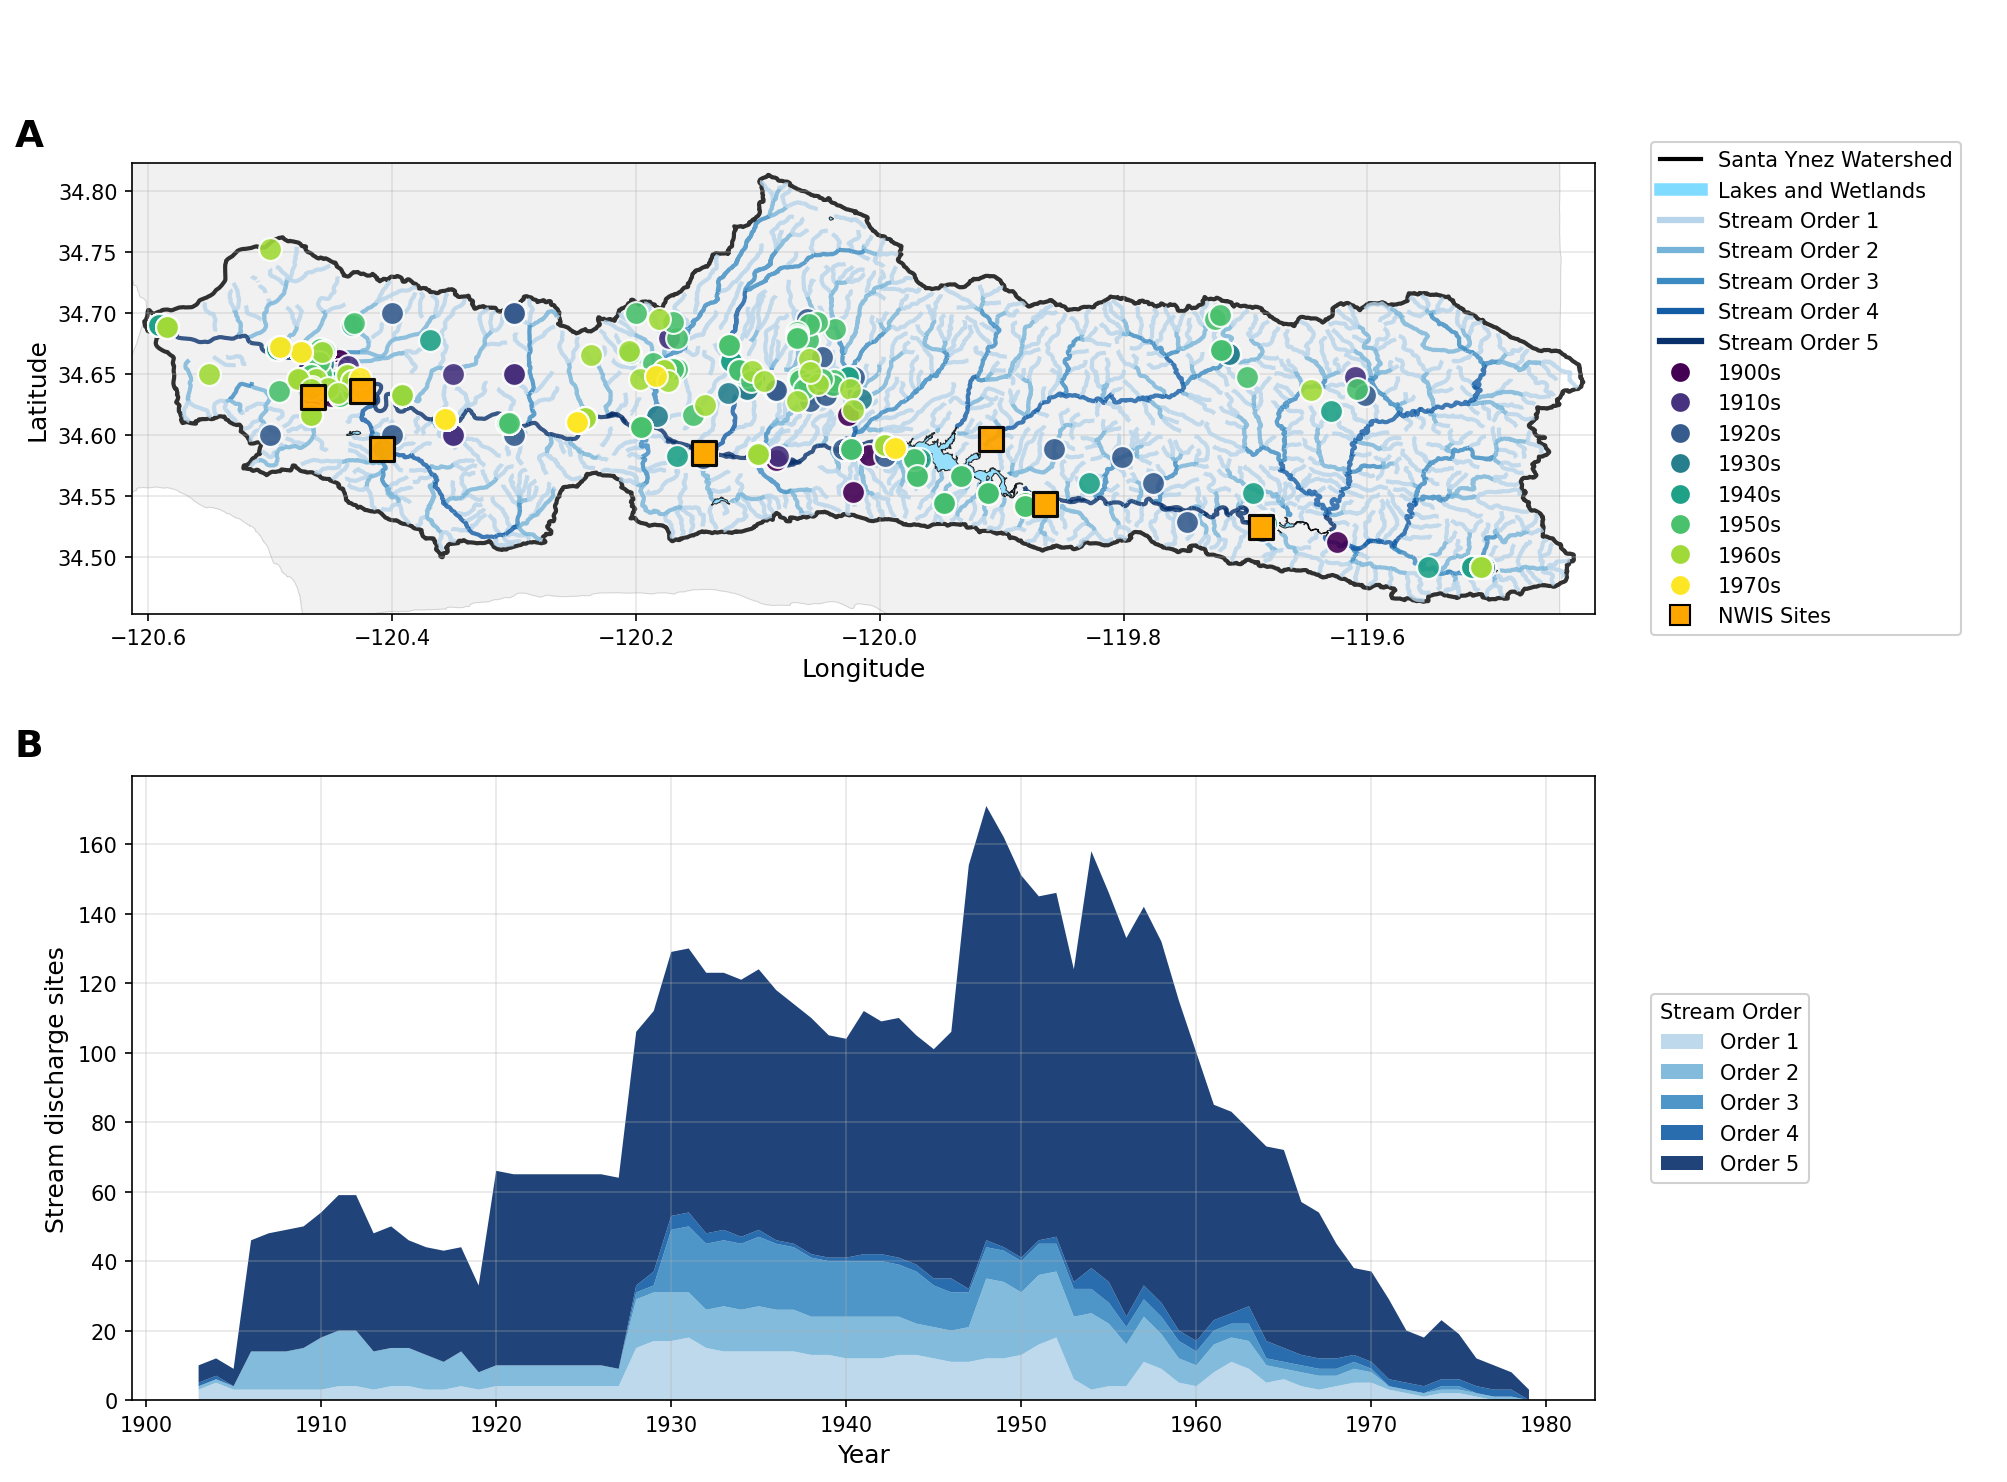


✓ Combined figure created!
✓ Map with 5 different stream orders
✓ Input sites provided: 707
✓ NWIS points plotted: 7
✓ Map plotted 34 lakes and wetlands
✓ Timeline shows data from 1903 to 1979


In [25]:
# === COMBINED FIGURE: Stream Order Map (Panel A) + Timeline (Panel B) ===
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import geopandas as gpd
from matplotlib.lines import Line2D
from collections import defaultdict

# ------------------------------------------------------------
# 1) Load the results DataFrame for timeline
# ------------------------------------------------------------
if 'stream_proximity_results' not in globals():
    results_path = r"C:\Users\aeliz\Dropbox\Documents\Jupyter Notebooks\chap2_usgs\data\stream_proximity_results.csv"
    stream_proximity_results = pd.read_csv(results_path)

df = stream_proximity_results.copy()
df['year_start'] = pd.to_numeric(df['year_start'], errors='coerce')
df['year_end']   = pd.to_numeric(df['year_end'], errors='coerce')
df['closest_stream_order'] = pd.to_numeric(df['closest_stream_order'], errors='coerce')
df = df.dropna(subset=['year_start', 'year_end', 'closest_stream_order'])
df['year_start'] = df['year_start'].astype(int)
df['year_end']   = df['year_end'].astype(int)
df['closest_stream_order'] = df['closest_stream_order'].astype(int)

# ------------------------------------------------------------
# 2) Load geographic data for map
# ------------------------------------------------------------
gdb_path = r"C:\Users\aeliz\Dropbox\Documents\Jupyter Notebooks\chap2_usgs\data\lakes\chap2map.gdb"
rivers = None
lakes  = None

gdb_exists = os.path.exists(gdb_path)
print(f"Geodatabase exists: {gdb_exists} - {gdb_path}")

try:
    if not gdb_exists:
        raise FileNotFoundError(f"GDB not found: {gdb_path}")

    rivers = gpd.read_file(gdb_path, layer="StreamsandRivers_Clip")
    lakes  = gpd.read_file(gdb_path, layer="LakesNationalWetlandsInventory_ExportFeatures")

    print(f"✓ Rivers loaded: {len(rivers)} features")
    print(f"✓ Lakes loaded:  {len(lakes)} features")

    if rivers.crs is not None and str(rivers.crs) != "EPSG:4326":
        print(f"Reprojecting rivers from {rivers.crs} -> EPSG:4326")
        rivers = rivers.to_crs("EPSG:4326")
    if lakes.crs is not None and str(lakes.crs) != "EPSG:4326":
        print(f"Reprojecting lakes from {lakes.crs} -> EPSG:4326")
        lakes = lakes.to_crs("EPSG:4326")

    if ('huc8_watershed' in globals()) and (huc8_watershed is not None) and (lakes is not None):
        if lakes.crs != huc8_watershed.crs:
            print("Converting lakes CRS to match watershed before clipping…")
            lakes = lakes.to_crs(huc8_watershed.crs)
        lakes_clipped = gpd.clip(lakes, huc8_watershed)
        print(f"✓ Clipped to watershed: {len(lakes_clipped)} lakes/wetlands within boundary")
        lakes = lakes_clipped if len(lakes_clipped) > 0 else None

except Exception as e:
    print(f"⚠ Error reading GDB layers: {e}")
    rivers, lakes = None, None

# --- NEW: ensure sb_county is available for plotting (EPSG:4326) ---
if 'sb_county' not in globals():
    try:
        _sb_path = r"C:\Users\aeliz\Dropbox\Documents\Jupyter Notebooks\chap2_usgs\data\sb_county_shapefile\sb_county_shp.shp"
        if os.path.exists(_sb_path):
            sb_county = gpd.read_file(_sb_path)
            if sb_county.crs is None or sb_county.crs.to_string() != "EPSG:4326":
                sb_county = sb_county.to_crs("EPSG:4326")
            print("✓ Loaded sb_county for basemap")
        else:
            print("Note: sb_county shapefile path not found; skipping county basemap")
    except Exception as e:
        print(f"Note: could not load sb_county: {e}")

# --- NEW: helper to clip points to HUC8 polygon ---
def _clip_points_to_huc(points_gdf, poly_gdf):
    if points_gdf is None or len(points_gdf) == 0 or poly_gdf is None:
        return points_gdf
    gdf = points_gdf
    if gdf.crs != poly_gdf.crs:
        gdf = gdf.to_crs(poly_gdf.crs)
    clipped = gpd.sjoin(gdf, poly_gdf[['geometry']], how='inner', predicate='within')
    if 'index_right' in clipped.columns:
        clipped = clipped.drop(columns=['index_right'])
    return clipped

# --- NEW: build NWIS GeoDataFrame from proximity results and clip to HUC8 (if present) ---
nwis_gdf = gpd.GeoDataFrame()
try:
    src_df = stream_proximity_results if 'stream_proximity_results' in globals() else df
    if isinstance(src_df, pd.DataFrame) and {'longitude', 'latitude'}.issubset(src_df.columns):
        nwis_pts = src_df[(src_df.get('data_type', '') == 'NWIS USGS') &
                          src_df['longitude'].notna() & src_df['latitude'].notna()]
        if len(nwis_pts) > 0:
            nwis_gdf = gpd.GeoDataFrame(
                nwis_pts,
                geometry=gpd.points_from_xy(nwis_pts['longitude'], nwis_pts['latitude']),
                crs="EPSG:4326"
            )
            if ('huc8_watershed' in globals()) and (huc8_watershed is not None):
                before = len(nwis_gdf)
                nwis_gdf = _clip_points_to_huc(nwis_gdf, huc8_watershed)
                removed = before - len(nwis_gdf)
                if removed:
                    print(f"Clipped NWIS points to HUC: removed {removed} point(s)")
except Exception as e:
    print(f"Note: NWIS point build failed: {e}")
    nwis_gdf = gpd.GeoDataFrame()

# --- NEW: clip existing santa_ynez_gdf to HUC8 as well (if both exist) ---
if ('santa_ynez_gdf' in globals()) and (len(santa_ynez_gdf) > 0) and ('huc8_watershed' in globals()) and (huc8_watershed is not None):
    before = len(santa_ynez_gdf)
    santa_ynez_gdf = _clip_points_to_huc(santa_ynez_gdf, huc8_watershed)
    removed = before - len(santa_ynez_gdf)
    if removed:
        print(f"Clipped santa_ynez_gdf to HUC: removed {removed} point(s)")

# ------------------------------------------------------------
# 3) Build timeline data
# ------------------------------------------------------------
counts = defaultdict(int)
for _, row in df.iterrows():
    ys, ye, order = row['year_start'], row['year_end'], row['closest_stream_order']
    if ys > ye:
        ys, ye = ye, ys
    for y in range(ys, ye + 1):
        counts[(y, order)] += 1

if counts:
    idx = pd.MultiIndex.from_tuples(counts.keys(), names=['year', 'closest_stream_order'])
    timeline = pd.Series(counts, index=idx).sort_index().rename('count').reset_index()
    pvt_t = timeline.pivot(index='year', columns='closest_stream_order', values='count').fillna(0).astype(int)
else:
    pvt_t = pd.DataFrame()

# ------------------------------------------------------------
# 4) Set up consistent color schemes
# ------------------------------------------------------------
stream_orders = []
stream_order_colors = {}

if (rivers is not None) and ('StreamOrderEdit' in rivers.columns):
    stream_orders = sorted(rivers['StreamOrderEdit'].dropna().unique())
    print(f"Stream orders found: {stream_orders}")

if not pvt_t.empty:
    timeline_orders = sorted(pvt_t.columns.tolist())
    if timeline_orders:
        stream_orders = timeline_orders

if stream_orders:
    n_orders = len(stream_orders)
    blues_colors = plt.cm.Blues(np.linspace(0.3, 1.0, n_orders))
    stream_order_colors = {order: blues_colors[i] for i, order in enumerate(stream_orders)}

decade_colors_map = {}
if 'santa_ynez_gdf' in globals() and (len(santa_ynez_gdf) > 0):
    if 'decade' in santa_ynez_gdf.columns:
        decades = sorted(santa_ynez_gdf['decade'].dropna().unique())
        viridis_colors = plt.cm.viridis(np.linspace(0, 1, len(decades)))
        decade_colors_map = dict(zip(decades, viridis_colors))

# ------------------------------------------------------------
# 5) Create combined figure (tight vertical spacing, no panel titles)
# ------------------------------------------------------------
fig = plt.figure(figsize=(16, 12), dpi=150)

# Minimal vertical space between panels
gs = fig.add_gridspec(
    2, 2,
    width_ratios=[5, 1.2],
    height_ratios=[1.2, 1],
    hspace=0.02,
    wspace=0.05
)

# =========================
# PANEL A - MAP (top left)
# =========================
ax_map = fig.add_subplot(gs[0, 0])

if 'sb_county' in globals() and sb_county is not None:
    sb_county.plot(ax=ax_map, color='lightgray', alpha=0.3, edgecolor='gray', linewidth=0.5)

if 'huc8_watershed' in globals() and (huc8_watershed is not None):
    huc8_watershed.plot(ax=ax_map, facecolor='none', edgecolor='black', linewidth=2, alpha=0.8)

if (rivers is not None) and ('StreamOrderEdit' in rivers.columns) and stream_orders:
    for order in stream_orders:
        if order in stream_order_colors:
            order_streams = rivers[rivers['StreamOrderEdit'] == order]
            if len(order_streams) > 0:
                order_streams.plot(ax=ax_map, color=stream_order_colors[order], linewidth=2, alpha=0.8, zorder=2)

if lakes is not None and len(lakes) > 0:
    lakes.plot(ax=ax_map, facecolor='#7FDBFF', edgecolor='black', linewidth=0.5, alpha=0.8, zorder=6)

if 'santa_ynez_gdf' in globals() and (len(santa_ynez_gdf) > 0):
    if 'decade' in santa_ynez_gdf.columns and decade_colors_map:
        for decade in decade_colors_map.keys():
            decade_sites = santa_ynez_gdf[santa_ynez_gdf['decade'] == decade]
            if len(decade_sites) > 0:
                decade_sites.plot(ax=ax_map, color=decade_colors_map[decade], markersize=120,
                                  alpha=0.9, edgecolor='white', linewidth=1, zorder=7)
    else:
        santa_ynez_gdf.plot(ax=ax_map, color='red', markersize=120, alpha=0.9,
                            edgecolor='white', linewidth=1, zorder=7)

# --- NEW: plot NWIS points (orange squares), already clipped if HUC is available ---
if 'nwis_gdf' in globals() and len(nwis_gdf) > 0:
    nwis_gdf.plot(ax=ax_map, color='orange', marker='s', markersize=140,
                  alpha=0.95, edgecolor='black', linewidth=1.5, zorder=9)

# Axes labels, no title
ax_map.set_xlabel('Longitude', fontsize=12)
ax_map.set_ylabel('Latitude', fontsize=12)

# Extent
if 'huc8_watershed' in globals() and (huc8_watershed is not None):
    minx, miny, maxx, maxy = huc8_watershed.total_bounds
    buffer = 0.01
    ax_map.set_xlim(minx - buffer, maxx + buffer)
    ax_map.set_ylim(miny - buffer, maxy + buffer)
elif 'santa_ynez_gdf' in globals() and (len(santa_ynez_gdf) > 0):
    minx, miny, maxx, maxy = santa_ynez_gdf.total_bounds
    buffer = 0.02
    ax_map.set_xlim(minx - buffer, maxx + buffer)
    ax_map.set_ylim(miny - buffer, maxy + buffer)

ax_map.grid(True, alpha=0.3)
ax_map.set_aspect('equal')

# Panel label "A" at far-left top
ax_map.text(-0.08, 1.02, "A", transform=ax_map.transAxes,
            fontsize=18, fontweight='bold', ha='left', va='bottom', clip_on=False)

# =========================
# MAP LEGEND (top right)
# =========================
ax_map_legend = fig.add_subplot(gs[0, 1])
ax_map_legend.axis('off')

legend_elements_map = []
if 'huc8_watershed' in globals() and (huc8_watershed is not None):
    legend_elements_map.append(Line2D([0], [0], color='black', linewidth=2, label='Santa Ynez Watershed'))
if lakes is not None and len(lakes) > 0:
    legend_elements_map.append(Line2D([0], [0], color='#7FDBFF', linewidth=6, label='Lakes and Wetlands'))
if stream_orders and stream_order_colors:
    for order in stream_orders:
        legend_elements_map.append(Line2D([0], [0], color=stream_order_colors[order], linewidth=3,
                                          label=f'Stream Order {int(order)}'))
if 'santa_ynez_gdf' in globals() and (len(santa_ynez_gdf) > 0):
    if decade_colors_map:
        for decade in sorted(decade_colors_map.keys()):
            legend_elements_map.append(Line2D([0], [0], marker='o', color='w',
                                              markerfacecolor=decade_colors_map[decade],
                                              markersize=10, label=f"{int(decade)}s",
                                              markeredgecolor='white'))
    else:
        legend_elements_map.append(Line2D([0], [0], marker='o', color='w',
                                          markerfacecolor='red', markersize=10,
                                          label='Gauge Sites', markeredgecolor='white'))
# NEW: add legend entry for NWIS squares (if present)
if 'nwis_gdf' in globals() and len(nwis_gdf) > 0:
    legend_elements_map.append(Line2D([0], [0], marker='s', color='w',
                                      markerfacecolor='orange', markeredgecolor='black',
                                      markersize=10, label='NWIS Sites'))

if legend_elements_map:
    ax_map_legend.legend(handles=legend_elements_map, loc='center left',
                         bbox_to_anchor=(0, 0.5), framealpha=0.9, fontsize=10)

# =========================
# PANEL B - TIMELINE (bottom left)
# =========================
ax_timeline = fig.add_subplot(gs[1, 0])

if not pvt_t.empty and stream_order_colors:
    years = pvt_t.index.values
    orders_sorted = sorted(pvt_t.columns.tolist())
    y_stacks = [pvt_t[o].values for o in orders_sorted]
    ax_timeline.stackplot(years, y_stacks,
                          labels=[f'Order {int(o)}' for o in orders_sorted],
                          colors=[stream_order_colors[o] for o in orders_sorted],
                          alpha=0.9)

ax_timeline.set_xlabel("Year", fontsize=12)
ax_timeline.set_ylabel("Stream discharge sites", fontsize=12)
ax_timeline.grid(True, alpha=0.3)

# Panel label "B" at far-left top
ax_timeline.text(-0.08, 1.02, "B", transform=ax_timeline.transAxes,
                 fontsize=18, fontweight='bold', ha='left', va='bottom', clip_on=False)

# =========================
# TIMELINE LEGEND (bottom right)
# =========================
ax_timeline_legend = fig.add_subplot(gs[1, 1])
ax_timeline_legend.axis('off')

if not pvt_t.empty and stream_order_colors:
    legend_elements_timeline = []
    orders_sorted = sorted(pvt_t.columns.tolist())
    for order in orders_sorted:
        legend_elements_timeline.append(
            plt.Rectangle((0, 0), 1, 1, facecolor=stream_order_colors[order], alpha=0.9, label=f'Order {int(order)}')
        )
    ax_timeline_legend.legend(handles=legend_elements_timeline, title="Stream Order",
                              loc='center left', bbox_to_anchor=(0, 0.5),
                              framealpha=0.9, fontsize=10)

# ------------------------------------------------------------
# 6) Save the combined figure
# ------------------------------------------------------------
outdir = r"C:\Users\aeliz\Dropbox\Documents\Jupyter Notebooks\chap2_usgs\plots"
os.makedirs(outdir, exist_ok=True)

plt.savefig(os.path.join(outdir, "combined_map_timeline_figure.png"),
            dpi=300, bbox_inches="tight")
plt.show()

print(f"\n✓ Combined figure created!")
print(f"✓ Map with {len(stream_orders) if stream_orders else 0} different stream orders")
if 'santa_ynez_gdf' in globals():
    print(f"✓ Input sites provided: {len(santa_ynez_gdf)}")
if 'nwis_gdf' in globals():
    print(f"✓ NWIS points plotted: {len(nwis_gdf)}")
if lakes is not None and len(lakes) > 0:
    print(f"✓ Map plotted {len(lakes)} lakes and wetlands")
if not pvt_t.empty:
    print(f"✓ Timeline shows data from {pvt_t.index.min()} to {pvt_t.index.max()}")
